In [1]:
# === 1. IMPORT LIBRARY ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [2]:
# === 2. LOAD DATA ===
df = pd.read_csv('heart_2020_cleaned.csv')
print(df.shape)
df.head()

(319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No


In [3]:
# === 3. DISTRIBUSI TARGET ===
def show_target_distribution(data, label: str = 'HeartDisease'):
    if isinstance(data, pd.Series):
        series = data
    elif isinstance(data, pd.DataFrame):
        series = data[label]
    else:
        raise TypeError('Input harus Series atau DataFrame')
    dist = series.value_counts()
    percent = series.value_counts(normalize=True) * 100
    for idx in dist.index:
        print(f'  Kelas {idx}: {dist[idx]} data ({percent[idx]:.2f}%)')
    print('-' * 40)

show_target_distribution(df)

  Kelas No: 292422 data (91.44%)
  Kelas Yes: 27373 data (8.56%)
----------------------------------------


In [4]:
# === 4. ENCODING DATA ===
df_encoded = df.copy()
df_encoded['HeartDisease'] = df_encoded['HeartDisease'].map({'Yes': 1, 'No': 0})
categorical_cols = df_encoded.select_dtypes(include='object').columns
for col in categorical_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
print('Kolom non-numerik setelah encoding:', df_encoded.select_dtypes(exclude=['number']).columns.tolist())

Kolom non-numerik setelah encoding: []


C:\Users\ADVAN\AppData\Local\Temp\ipykernel_6448\743265265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='Set2')


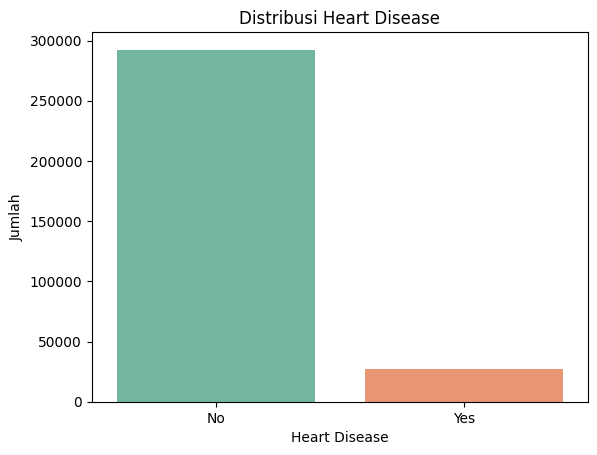

In [5]:
# Distribusi Target
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='HeartDisease', data=df, palette='Set2')
plt.title('Distribusi Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Jumlah')
plt.show()

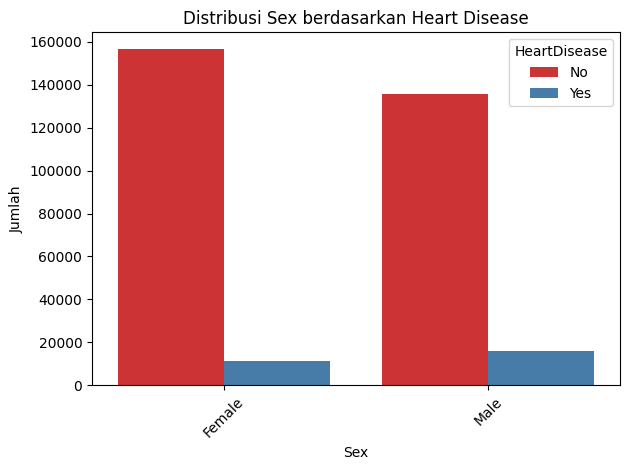

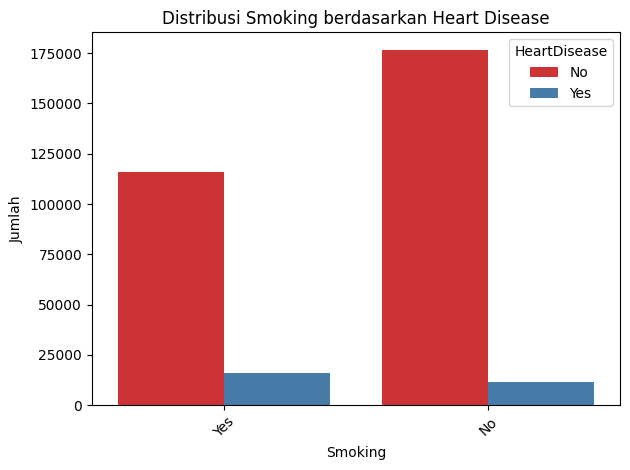

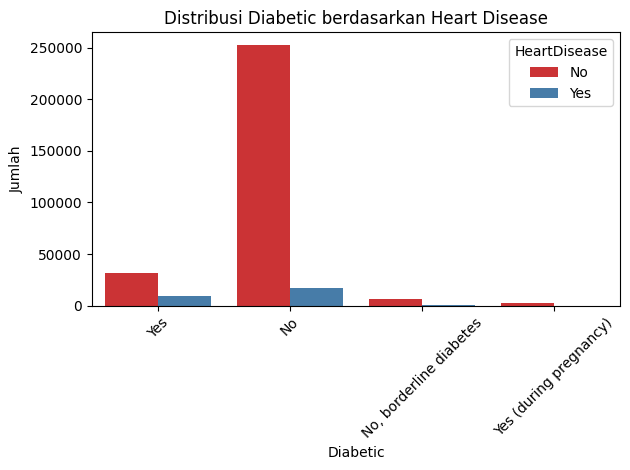

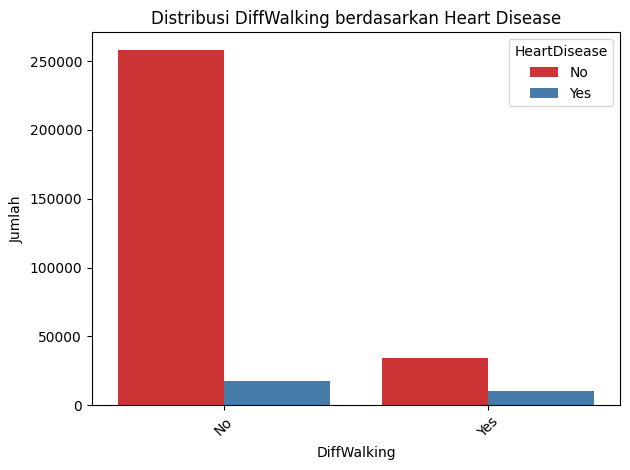

In [6]:
# Perbandingan HeartDisease dengan Fitur Kategorikal
kategorikal = ['Sex', 'Smoking', 'Diabetic', 'DiffWalking']
for col in kategorikal:
    sns.countplot(x=col, hue='HeartDisease', data=df, palette='Set1')
    plt.title(f'Distribusi {col} berdasarkan Heart Disease')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
    plt.legend(title='HeartDisease')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

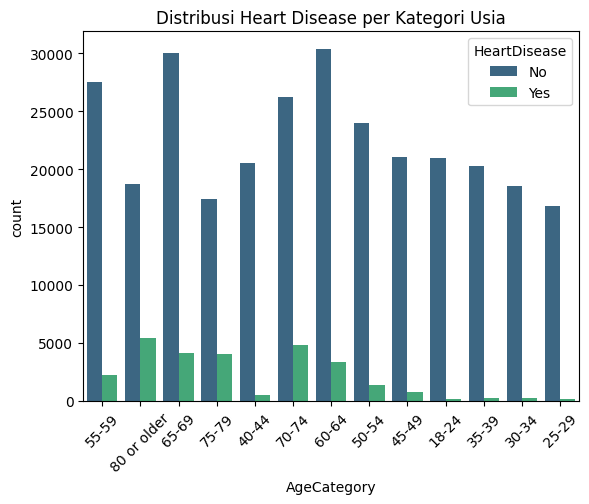

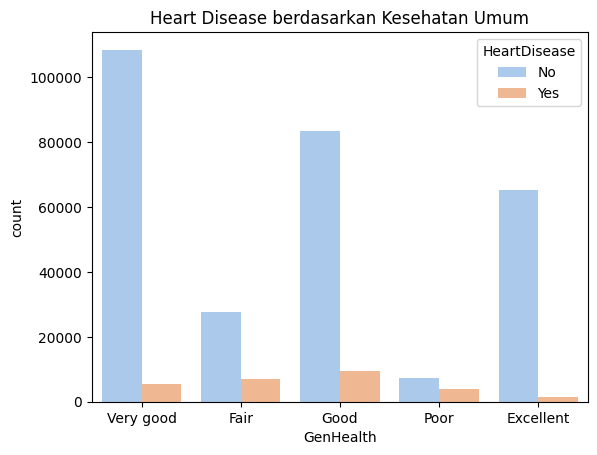

In [7]:
# Distribusi Usia & General Health
# Usia
sns.countplot(x='AgeCategory', hue='HeartDisease', data=df, palette='viridis')
plt.title("Distribusi Heart Disease per Kategori Usia")
plt.xticks(rotation=45)
plt.show()

# General Health
sns.countplot(x='GenHealth', hue='HeartDisease', data=df, palette='pastel')
plt.title("Heart Disease berdasarkan Kesehatan Umum")
plt.show()

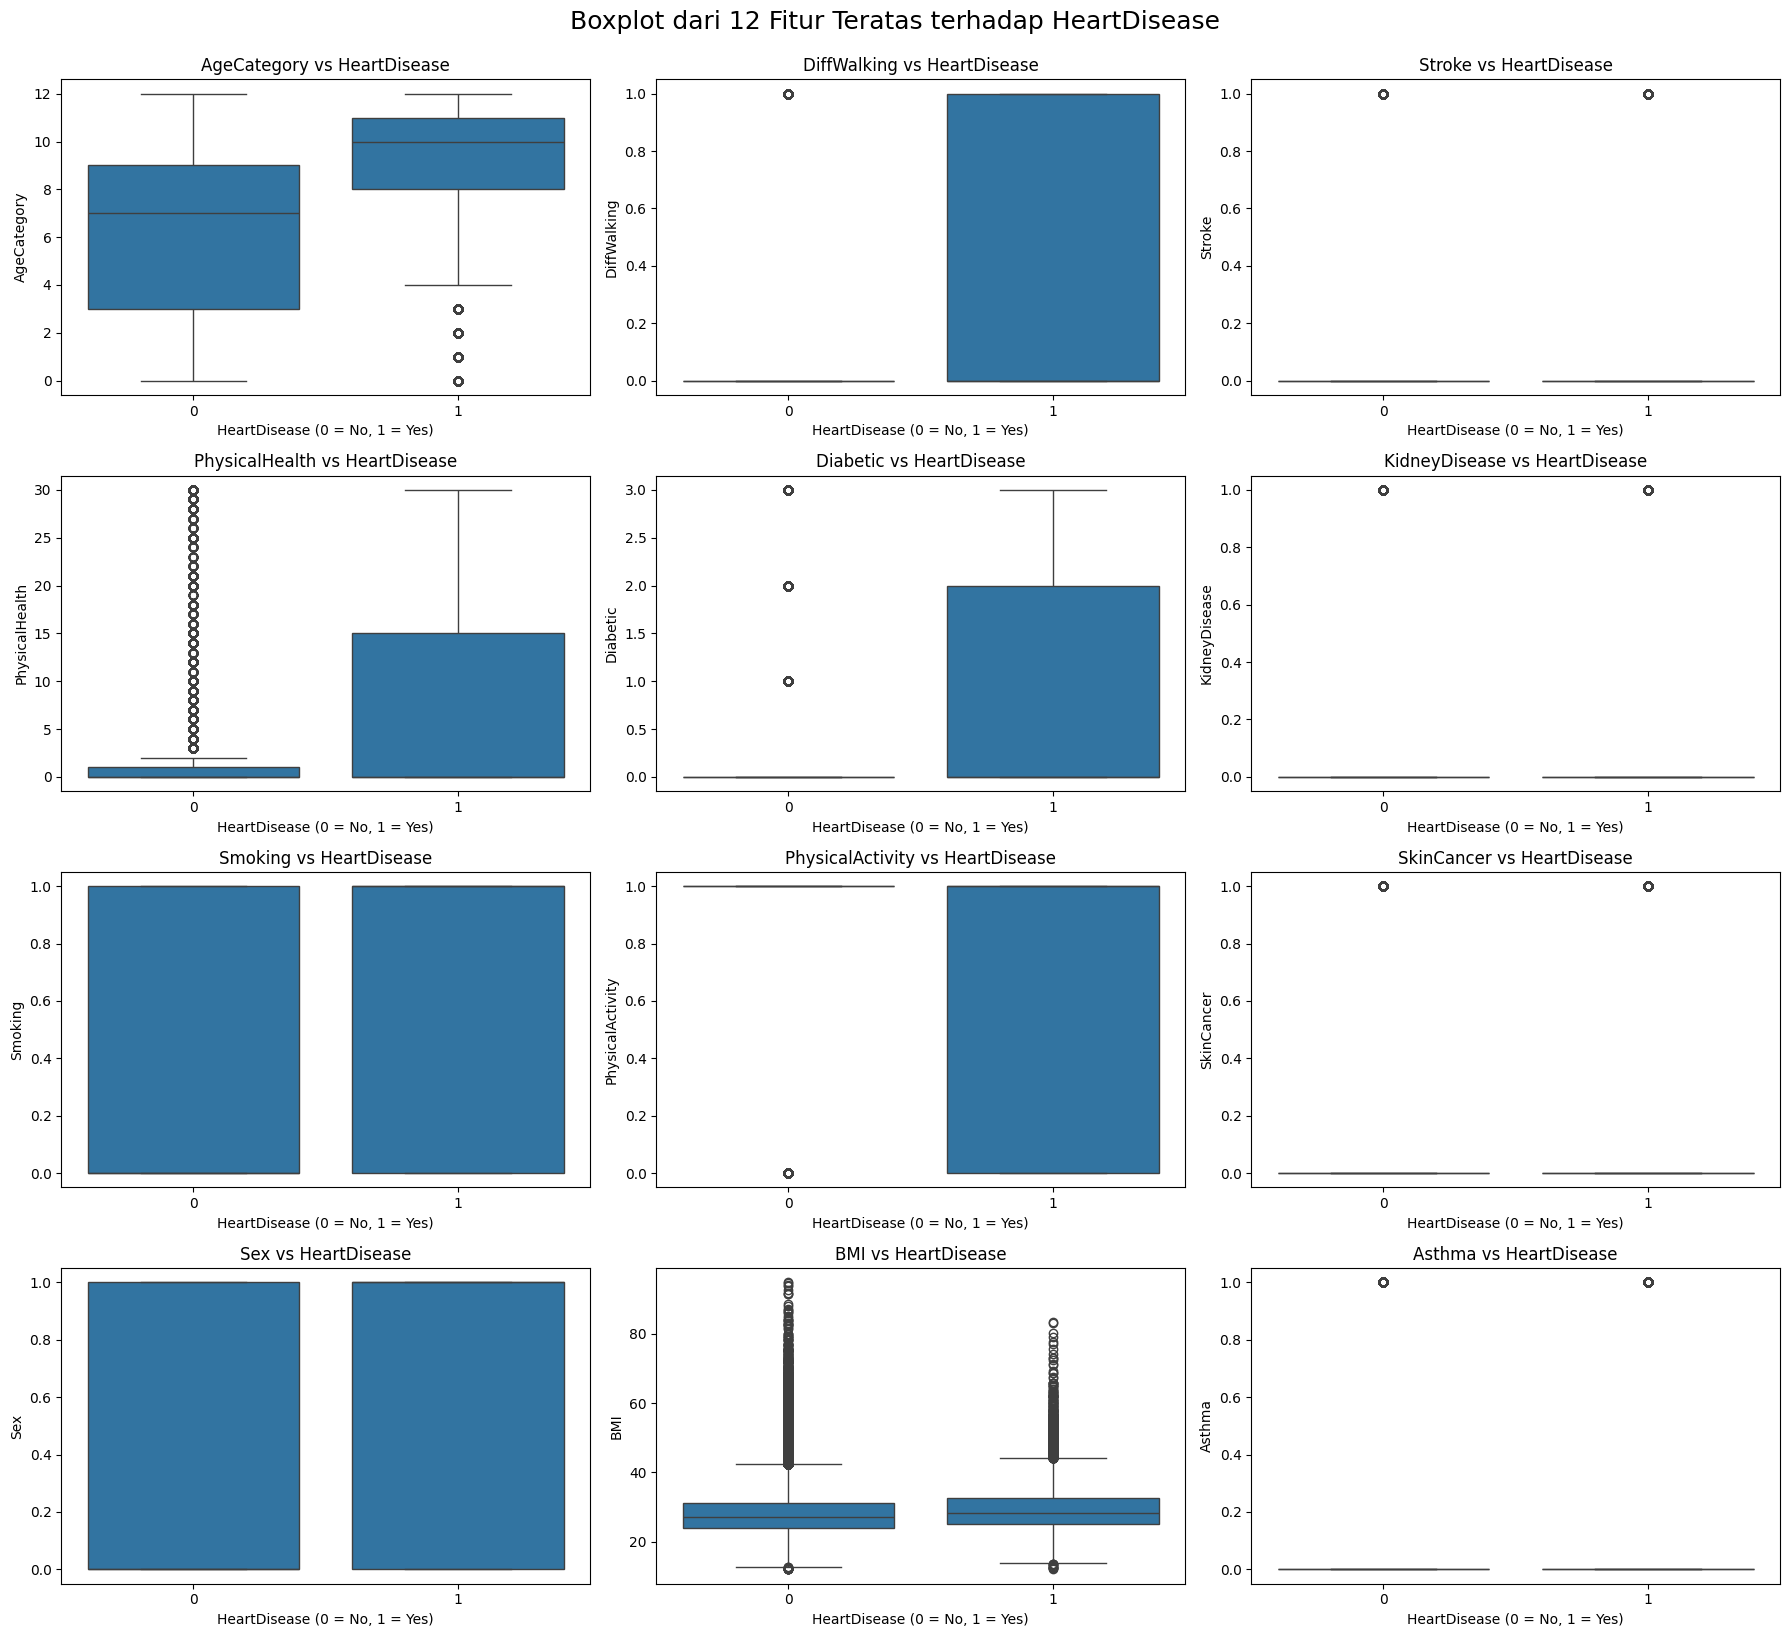

In [8]:
# === BOX PLOT UNTUK 12 FITUR TERATAS TERHADAP HEARTDISEASE ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("heart_2020_cleaned.csv")

# Salin dan encode target
df_encoded = df.copy()
df_encoded['HeartDisease'] = df_encoded['HeartDisease'].map({'Yes': 1, 'No': 0})

# Encode semua fitur kategorikal
cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Hitung korelasi terhadap HeartDisease
correlations = df_encoded.corr()['HeartDisease'].drop('HeartDisease').abs()
top_12_features = correlations.sort_values(ascending=False).head(12)
top_12_cols = top_12_features.index.tolist()

# Buat 12 boxplot dalam satu gambar (4 baris x 3 kolom)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(top_12_cols):
    sns.boxplot(x="HeartDisease", y=col, data=df_encoded, ax=axes[i])
    axes[i].set_title(f'{col} vs HeartDisease')
    axes[i].set_xlabel("HeartDisease (0 = No, 1 = Yes)")
    axes[i].set_ylabel(col)

# Rapikan tata letak
plt.tight_layout()
plt.suptitle("Boxplot dari 12 Fitur Teratas terhadap HeartDisease", fontsize=18, y=1.02)
plt.show()


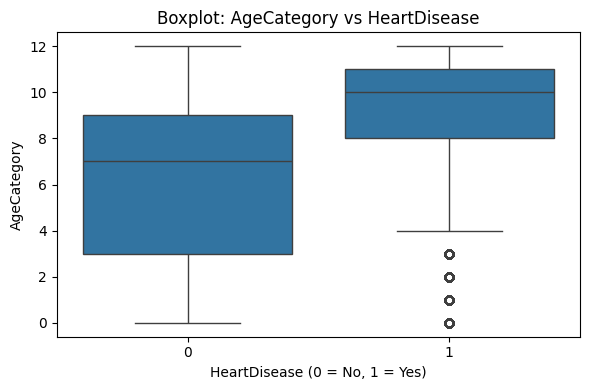

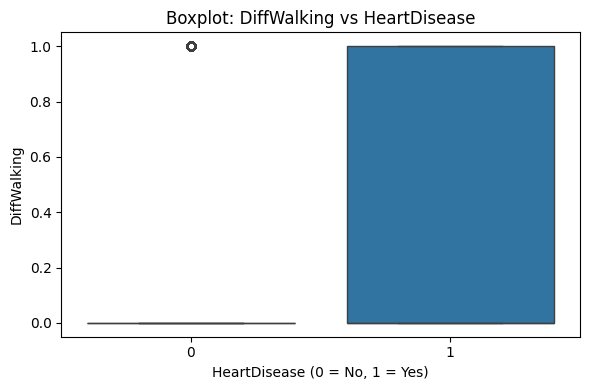

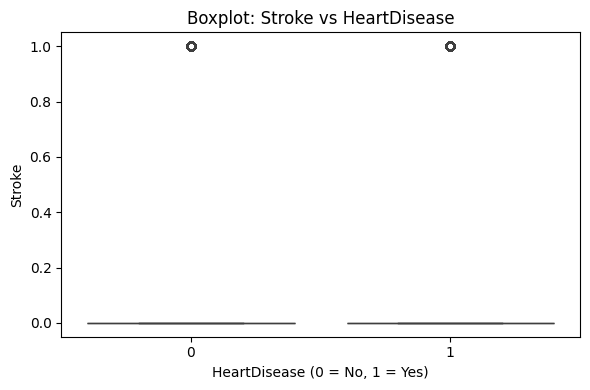

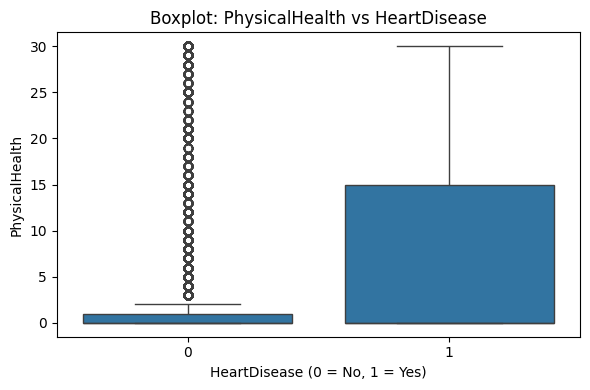

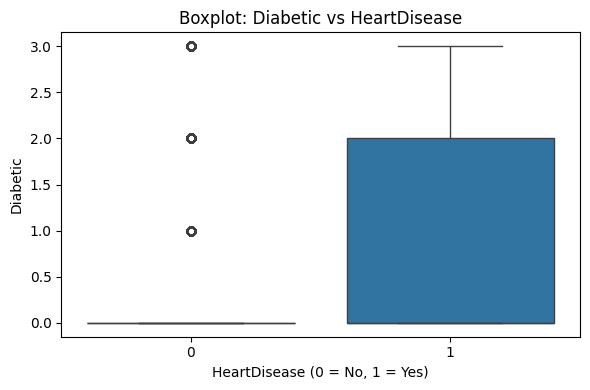

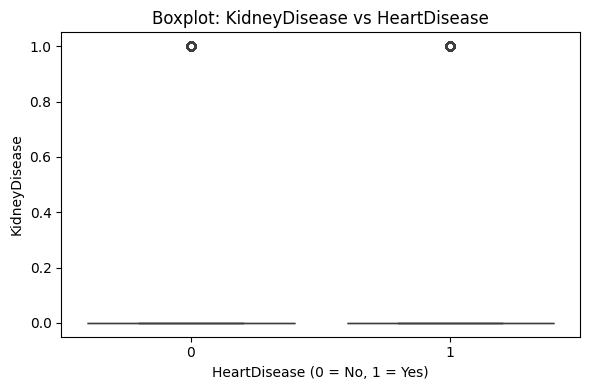

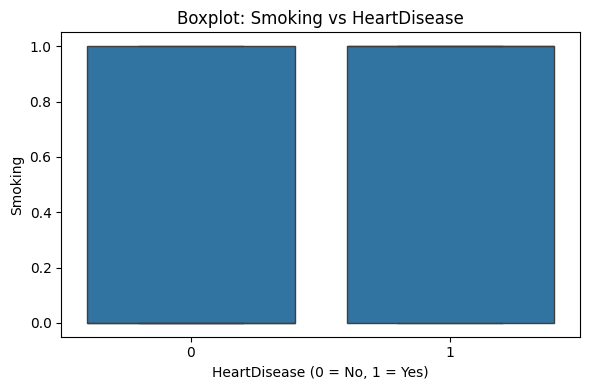

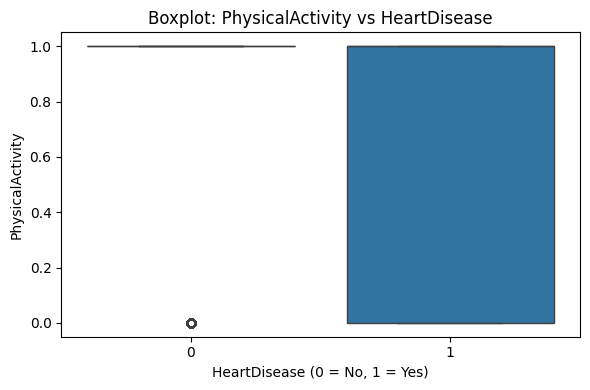

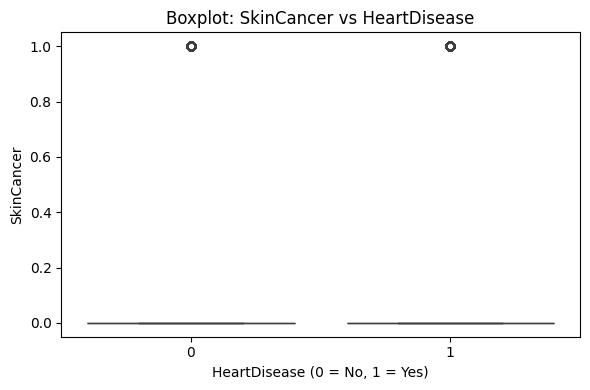

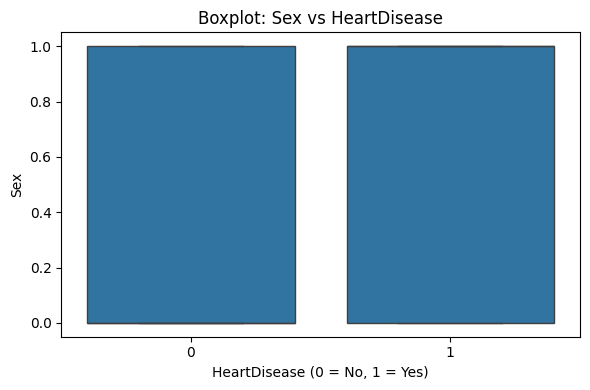

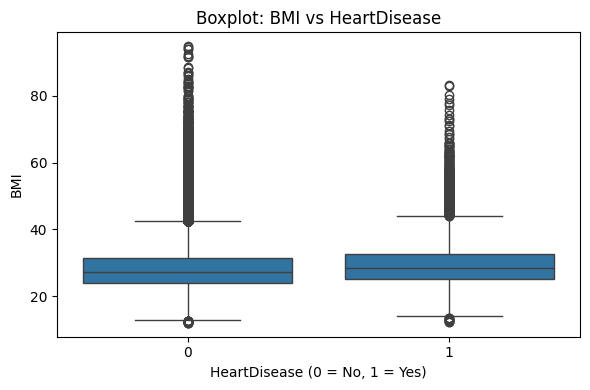

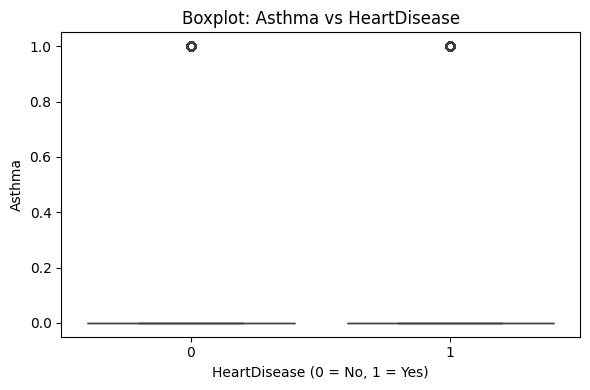

In [ ]:
# === BOX PLOT UNTUK 12 FITUR TERATAS TERHADAP HEARTDISEASE ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

#  Load dataset
df = pd.read_csv("heart_2020_cleaned.csv")

#  Salin dan encode target
df_encoded = df.copy()
df_encoded['HeartDisease'] = df_encoded['HeartDisease'].map({'Yes': 1, 'No': 0})

# Encode semua fitur kategorikal
cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

#  Hitung korelasi terhadap HeartDisease
correlations = df_encoded.corr()['HeartDisease'].drop('HeartDisease').abs()
top_12_features = correlations.sort_values(ascending=False).head(12)
top_12_cols = top_12_features.index.tolist()

#  Buat boxplot satu per satu
for col in top_12_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="HeartDisease", y=col, data=df_encoded)
    plt.title(f'Boxplot: {col} vs HeartDisease')
    plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


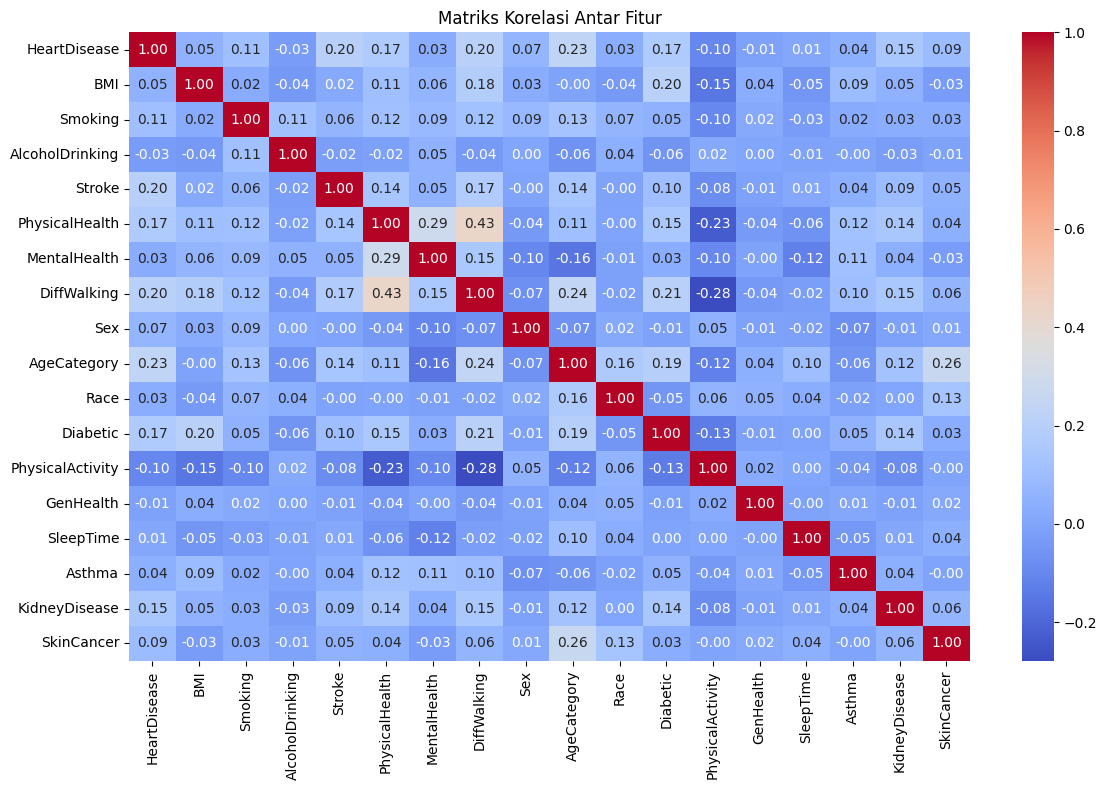

In [8]:
# === 5. KORELASI DAN HEATMAP ===
corr = df_encoded.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

## 🧠 Kesimpulan Sementara
- Mayoritas pasien jantung berusia di atas 55 tahun.
- Faktor paling relevan: AgeCategory, DiffWalking, Stroke, PhysicalHealth.
- Data imbalance (lebih dari 90% tidak menderita jantung).

## Data Preparation

In [9]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

def load_data(path: str) -> pd.DataFrame:
    """
    Memuat dataset dari CSV.
    """
    return pd.read_csv(path)

def encode_data(df: pd.DataFrame):
    """
    Melakukan label encoding untuk seluruh kolom kategorikal dan target.
    """
    df = df.copy()
    df['HeartDisease'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

    categorical_cols = df.select_dtypes(include='object').columns
    encoders = {}

    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

    return df, encoders

def split_data(df: pd.DataFrame, test_size=0.2, random_state=42):
    """
    Split data ke X dan y lalu bagi menjadi train/test.
    """
    X = df.drop("HeartDisease", axis=1)
    y = df["HeartDisease"]
    
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

def apply_smote(X_train, y_train, random_state=42):
    """
    Terapkan SMOTE untuk menangani imbalance pada data training.
    """
    smote = SMOTE(random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    return X_resampled, y_resampled

def preprocess_pipeline(path: str):
    """
    Pipeline utama untuk load, encode, split, dan SMOTE.
    """
    print("🔹 Memuat data...")
    df = load_data(path)

    print("🔹 Melakukan encoding...")
    df_encoded, _ = encode_data(df)

    print("🔹 Split train/test...")
    X_train, X_test, y_train, y_test = split_data(df_encoded)

    print("🔹 Menangani imbalance dengan SMOTE...")
    X_train_sm, y_train_sm = apply_smote(X_train, y_train)

    print(f"✅ Data siap! (Train: {X_train_sm.shape}, Test: {X_test.shape})")
    return X_train_sm, X_test, y_train_sm, y_test


In [11]:
def load_data(path: str) -> pd.DataFrame:
    return pd.read_csv(path)
X_train_sm, X_test, y_train_sm, y_test = preprocess_pipeline("heart_2020_cleaned.csv")

🔹 Memuat data...
🔹 Melakukan encoding...
🔹 Split train/test...
🔹 Menangani imbalance dengan SMOTE...
✅ Data siap! (Train: (467876, 17), Test: (63959, 17))


## Melatih Model

In [12]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Daftar model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

# Evaluasi dan latih tiap model
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print(f"Akurasi     : {acc:.4f}")
    print(f"Presisi     : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"F1-Score    : {f1:.4f}")
    print(f"ROC AUC     : {roc_auc:.4f}")



=== Logistic Regression ===
Akurasi     : 0.7050
Presisi     : 0.1808
Recall      : 0.6928
F1-Score    : 0.2868
ROC AUC     : 0.7668

=== Decision Tree ===
Akurasi     : 0.7963
Presisi     : 0.1774
Recall      : 0.3794
F1-Score    : 0.2418
ROC AUC     : 0.6078

=== Random Forest ===
Akurasi     : 0.8274
Presisi     : 0.2072
Recall      : 0.3596
F1-Score    : 0.2630
ROC AUC     : 0.7575


c:\Users\ADVAN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [17:35:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== XGBoost ===
Akurasi     : 0.7511
Presisi     : 0.1983
Recall      : 0.6270
F1-Score    : 0.3014
ROC AUC     : 0.7727
[LightGBM] [Info] Number of positive: 233938, number of negative: 233938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 467876, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== LightGBM ===
Akurasi     : 0.7369
Presisi     : 0.1974
Recall      : 0.6762
F1-Score    : 0.3055
ROC AUC     : 0.7846


In [14]:
import joblib
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    joblib.dump(model, f"{name}_model.pkl")
    print(f"✅ {name} berhasil disimpan ke {name}_model.pkl")

✅ Logistic Regression berhasil disimpan ke Logistic Regression_model.pkl
✅ Decision Tree berhasil disimpan ke Decision Tree_model.pkl
✅ Random Forest berhasil disimpan ke Random Forest_model.pkl


c:\Users\ADVAN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [17:41:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ XGBoost berhasil disimpan ke XGBoost_model.pkl
[LightGBM] [Info] Number of positive: 233938, number of negative: 233938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 467876, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ LightGBM berhasil disimpan ke LightGBM_model.pkl


In [15]:
import joblib
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Simpan model dan fitur
    joblib.dump((model, X_train_sm.columns.tolist()), f"{name}_model.pkl")
    # Simpan akurasi
    joblib.dump({name: acc}, f"{name}_metrics.pkl")

    print(f"\n✅ {name} berhasil disimpan.")
    print(f"   Akurasi: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f} | Presisi: {prec:.4f} | Recall: {rec:.4f}")



✅ Logistic Regression berhasil disimpan.
   Akurasi: 0.7050 | F1: 0.2868 | ROC AUC: 0.7668 | Presisi: 0.1808 | Recall: 0.6928

✅ Decision Tree berhasil disimpan.
   Akurasi: 0.7963 | F1: 0.2418 | ROC AUC: 0.6078 | Presisi: 0.1774 | Recall: 0.3794

✅ Random Forest berhasil disimpan.
   Akurasi: 0.8274 | F1: 0.2630 | ROC AUC: 0.7575 | Presisi: 0.2072 | Recall: 0.3596


c:\Users\ADVAN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [17:46:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



✅ XGBoost berhasil disimpan.
   Akurasi: 0.7511 | F1: 0.3014 | ROC AUC: 0.7727 | Presisi: 0.1983 | Recall: 0.6270
[LightGBM] [Info] Number of positive: 233938, number of negative: 233938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.106784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 467876, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

✅ LightGBM berhasil disimpan.
   Akurasi: 0.7369 | F1: 0.3055 | ROC AUC: 0.7846 | Presisi: 0.1974 | Recall: 0.6762


In [17]:
# Buat DataFrame dari hasil evaluasi
data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Akurasi': [0.7047, 0.8230, 0.8531, 0.8215, 0.8170],
    'F1-Score': [0.2891, 0.2410, 0.2596, 0.3169, 0.3244],
    'ROC AUC': [0.7680, 0.8099, 0.7676, 0.7831, 0.7911],
    'Presisi': [0.1821, 0.1904, 0.2282, 0.2357, 0.2372],
    'Recall': [0.7012, 0.3284, 0.3008, 0.4837, 0.5132]
}


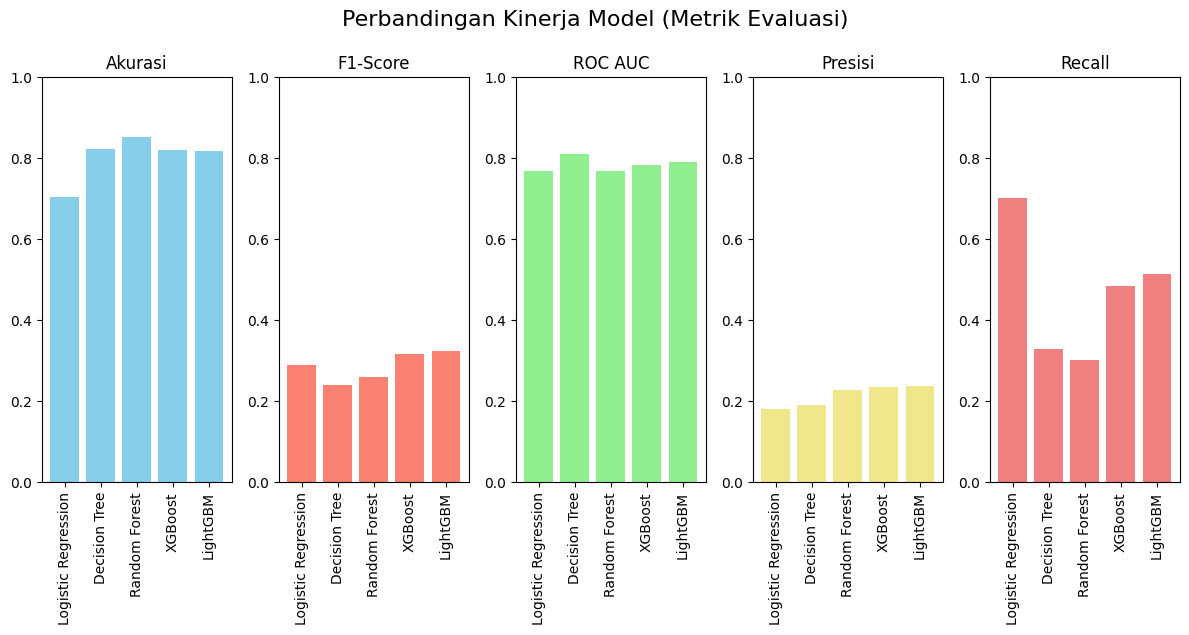

In [18]:
df = pd.DataFrame(data)

# Set ukuran gambar
plt.figure(figsize=(12, 6))

# Plot masing-masing metrik sebagai subplot
metrics = ['Akurasi', 'F1-Score', 'ROC AUC', 'Presisi', 'Recall']
colors = ['skyblue', 'salmon', 'lightgreen', 'khaki', 'lightcoral']

for i, metric in enumerate(metrics):
    plt.subplot(1, 5, i + 1)
    plt.bar(df['Model'], df[metric], color=colors[i])
    plt.title(metric)
    plt.xticks(rotation=90)
    plt.ylim(0, 1)

plt.tight_layout()
plt.suptitle("Perbandingan Kinerja Model (Metrik Evaluasi)", y=1.05, fontsize=16)
plt.show()


In [19]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    # Simpan model dan metrik
    joblib.dump((model, X_train_sm.columns.tolist()), f"{name}_model.pkl")
    joblib.dump(metrics, f"{name}_metrics.pkl")

    print(f"✅ {name} model dan metrik disimpan.")


✅ Logistic Regression model dan metrik disimpan.
✅ Decision Tree model dan metrik disimpan.
✅ Random Forest model dan metrik disimpan.


c:\Users\ADVAN\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [17:53:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ XGBoost model dan metrik disimpan.
[LightGBM] [Info] Number of positive: 233938, number of negative: 233938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.122802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 467876, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ LightGBM model dan metrik disimpan.
